# Men's March Madness: Offense vs. Defense

## Research Question

Does having a strong offense or strong defense matter more for success in the men's NCAA Tournament?

I chose this question because I watch a lot of college basketball and wanted to see what actually matters more for teams in March Madness. I am comparing adjusted offensive efficiency and adjusted defensive efficiency to how far a team advances in the tournament. Previous research has looked at how different team statistics and efficiency ratings are connected to success in March Madness (Pifer et al., 2019). 

In [40]:
import os
print(os.getcwd())

c:\Users\willa\Downloads


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

## Data Description

For this project, I am using a college basketball dataset that includes Division I men's basketball teams from multiple seasons. The dataset includes team statistics such as adjusted offensive efficiency, adjusted defensive efficiency, NCAA Tournament seed, and postseason result.

I filtered the data to only include teams that made the NCAA Tournament. After filtering, there are 816 tournament team records in the data. Each row represents one team from one season.

The main variables I am using are ADJOE for adjusted offensive efficiency, ADJDE for adjusted defensive efficiency, and POSTSEASON for how far each team went in the tournament. The dataset I used was the College Basketball Dataset created by Andrew Sundberg on Kaggle. The dataset includes Division I men's college basketball statistics and tournament results from multiple seasons.

In [42]:
df = pd.read_csv("cbb.csv")

df.head()

,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017


In [43]:
df.columns

Index(['TEAM', 'CONF', 'G', 'W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
       'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', '2P_O', '2P_D', '3P_O',
       '3P_D', 'ADJ_T', 'WAB', 'POSTSEASON', 'SEED', 'YEAR'],
      dtype='str')

## Data Cleaning and Preparation

I started by loading the data into pandas and looking through the columns. Since I am only looking at March Madness, I filtered the data so it only included teams that made the NCAA Tournament.

After that, I kept the columns that I needed for my project like the team, year, seed, offensive efficiency, defensive efficiency, and how far the team made it in the tournament. I also checked for missing data and duplicates and there were none.

I then made a new column called tournament advancement score. I used how far each team made it in the tournament to give them a score from 0 to 7. Teams that lost in the First Four received a 0, while the national champion received a 7. This made it easier to compare tournament success to offense and defense.

In [44]:
tournament = df[df["SEED"].notna()].copy()

tournament.shape

(816, 24)

In [45]:
tournament = tournament[
    ["TEAM", "YEAR", "SEED", "ADJOE", "ADJDE", "POSTSEASON"]
]

tournament.head()

,TEAM,YEAR,SEED,ADJOE,ADJDE,POSTSEASON
0,North Carolina,2016,1.0,123.3,94.9,2ND
1,Wisconsin,2015,1.0,129.1,93.6,2ND
2,Michigan,2018,3.0,114.4,90.4,2ND
3,Texas Tech,2019,3.0,115.2,85.2,2ND
4,Gonzaga,2017,1.0,117.8,86.3,2ND


In [46]:
tournament.isnull().sum()

TEAM          0
YEAR          0
SEED          0
ADJOE         0
ADJDE         0
POSTSEASON    0
dtype: int64

In [47]:
tournament.duplicated().sum()

np.int64(0)

In [48]:
tournament["POSTSEASON"].value_counts()

POSTSEASON
R64          384
R32          192
S16           96
E8            48
R68           48
F4            24
2ND           12
Champions     12
Name: count, dtype: int64

In [49]:
round_score = {
    "R68": 0,
    "R64": 1,
    "R32": 2,
    "S16": 3,
    "E8": 4,
    "F4": 5,
    "2ND": 6,
    "Champions": 7
}

tournament["ADVANCEMENT_SCORE"] = tournament["POSTSEASON"].map(round_score)

tournament.head()

,TEAM,YEAR,SEED,ADJOE,ADJDE,POSTSEASON,ADVANCEMENT_SCORE
0,North Carolina,2016,1.0,123.3,94.9,2ND,6
1,Wisconsin,2015,1.0,129.1,93.6,2ND,6
2,Michigan,2018,3.0,114.4,90.4,2ND,6
3,Texas Tech,2019,3.0,115.2,85.2,2ND,6
4,Gonzaga,2017,1.0,117.8,86.3,2ND,6


## Visualizations and Results

I made scatter plots to compare offensive and defensive efficiency to how far teams advanced in the tournament. A higher offensive efficiency means a better offense, while a lower defensive efficiency means a better defense.

I wanted to see if teams with better offense or defense usually made it farther in March Madness. Other research has also found that different offensive and defensive statistics can help separate winning teams from losing teams in college basketball (Cabarkapa et al., 2024).

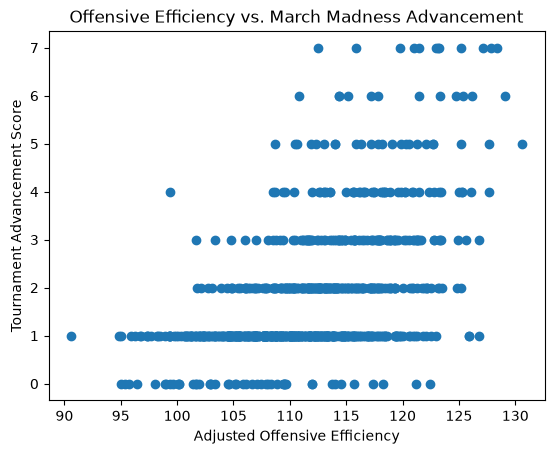

In [50]:
plt.scatter(tournament["ADJOE"], tournament["ADVANCEMENT_SCORE"])
plt.xlabel("Adjusted Offensive Efficiency")
plt.ylabel("Tournament Advancement Score")
plt.title("Offensive Efficiency vs. March Madness Advancement")
plt.show()

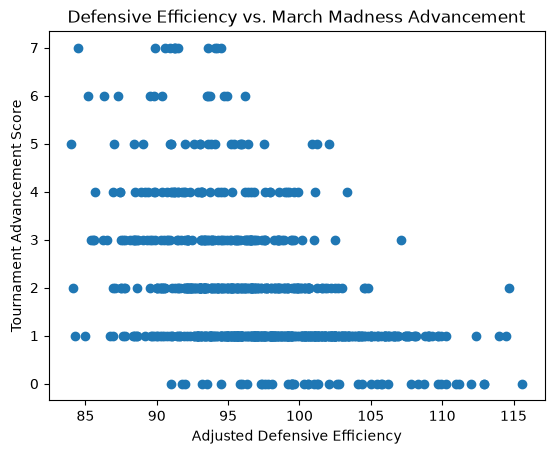

In [51]:
plt.scatter(tournament["ADJDE"], tournament["ADVANCEMENT_SCORE"])

plt.xlabel("Adjusted Defensive Efficiency")
plt.ylabel("Tournament Advancement Score")
plt.title("Defensive Efficiency vs. March Madness Advancement")

plt.show()

In [52]:
offense_corr = tournament["ADJOE"].corr(tournament["ADVANCEMENT_SCORE"])
defense_corr = tournament["ADJDE"].corr(tournament["ADVANCEMENT_SCORE"])

print("Offense correlation:", offense_corr)
print("Defense correlation:", defense_corr)

Offense correlation: 0.5248223962297232
Defense correlation: -0.4448422753450007


The offense correlation was about 0.52 and the defense correlation was about -0.44. The defense number is negative because a lower defensive efficiency is better.

This shows that both offense and defense are related to how far teams advance in the tournament, but offense had the stronger relationship in this data.

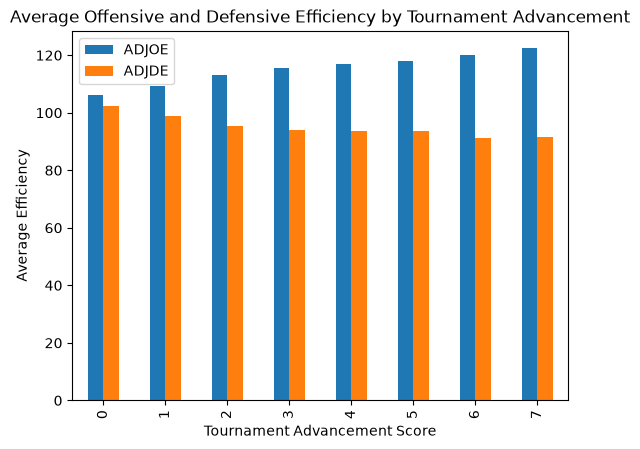

In [53]:
round_averages = tournament.groupby("ADVANCEMENT_SCORE")[["ADJOE", "ADJDE"]].mean()

round_averages.plot(kind="bar")

plt.xlabel("Tournament Advancement Score")
plt.ylabel("Average Efficiency")
plt.title("Average Offensive and Defensive Efficiency by Tournament Advancement")

plt.show()

### Bar Chart Results

The bar chart shows the average offensive and defensive efficiency for teams based on how far they advanced in the tournament. As the advancement score went up, offensive efficiency generally got better and defensive efficiency also improved.

This shows that teams that make deeper runs in March Madness are usually good on both sides of the ball. Offense still showed a stronger relationship with tournament success based on the correlation results.

## Storytelling and Narrative

The main thing I found from this project is that teams that go farther in March Madness are usually good on both offense and defense. The graphs showed that teams that advanced farther generally had better offensive and defensive efficiency.

When I compared the correlations, offense had a stronger relationship with tournament advancement than defense. This does not mean that offense is the only thing that matters, but based on this data it seems to have a bigger relationship with how far a team goes in the tournament.

## Limitations and Ethics

There are some limitations with this data. A team's offense and defense are not the only things that decide how far they make it in March Madness. Injuries, matchups, seeding, and even one bad game can change the result of a team's tournament.

Another limitation is that this project only looks at the relationship between efficiency and tournament wins. The results do not prove that having a better offense causes a team to win more games.

There are not many ethical concerns with this project because the data is about college basketball teams and does not include private information about individual people. I also want to make sure I give credit to where the data came from and explain how I used AI during the project. There are also many other factors that can affect tournament results, and past research has used multiple team statistics when trying to predict NCAA Tournament upsets (Dutta et al., 2017).

## Code and AI Transparency

For this project, I used Python with pandas and matplotlib to clean the data, look at the relationships between variables, and make my graphs. I reviewed the code as I worked through it so I understood what each part was doing.

I used ChatGPT to help me understand some of the Python code, troubleshoot problems, and to help explain some of my results. I reviewed the information and made changes when needed.

## References

Pifer, N. D., DeSchriver, T. D., Baker, T. A., & Zhang, J. J. (2019). The advantage of experience: Analyzing the effects of player experience on the performances of March Madness teams. *Journal of Sports Analytics*. https://doi.org/10.3233/JSA-180331

Cabarkapa, D., Cabarkapa, D. V., & Fry, A. C. (2024). Game-related statistics that discriminate winning from losing in NCAA Division-I men's basketball. *Frontiers in Sports and Active Living, 6*, 1387918. https://doi.org/10.3389/fspor.2024.1387918

Dutta, S., Jacobson, S. H., & Sauppe, J. J. (2017). Identifying NCAA tournament upsets using Balance Optimization Subset Selection. *Journal of Quantitative Analysis in Sports, 13*(2), 79–93. https://doi.org/10.1515/jqas-2016-0062

Sundberg, A. (n.d.). College Basketball Dataset. Kaggle.